In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dt_clf = DecisionTreeClassifier(random_state=42)

iris_data = load_iris()
X_train , X_test , y_train , y_test = train_test_split(iris_data.data, iris_data.target,
                                                       test_size=0.2,  random_state=42)

dt_clf.fit(X_train , y_train);

In [5]:
from sklearn.tree import export_graphviz

export_graphviz(dt_clf, out_file="tree.dot", class_names=iris_data.target_names,
                feature_names = iris_data.feature_names, impurity=True, filled=True)

In [7]:
import os
import sys

# Graphviz bin 폴더 경로를 파이썬 실행 환경에 추가
os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

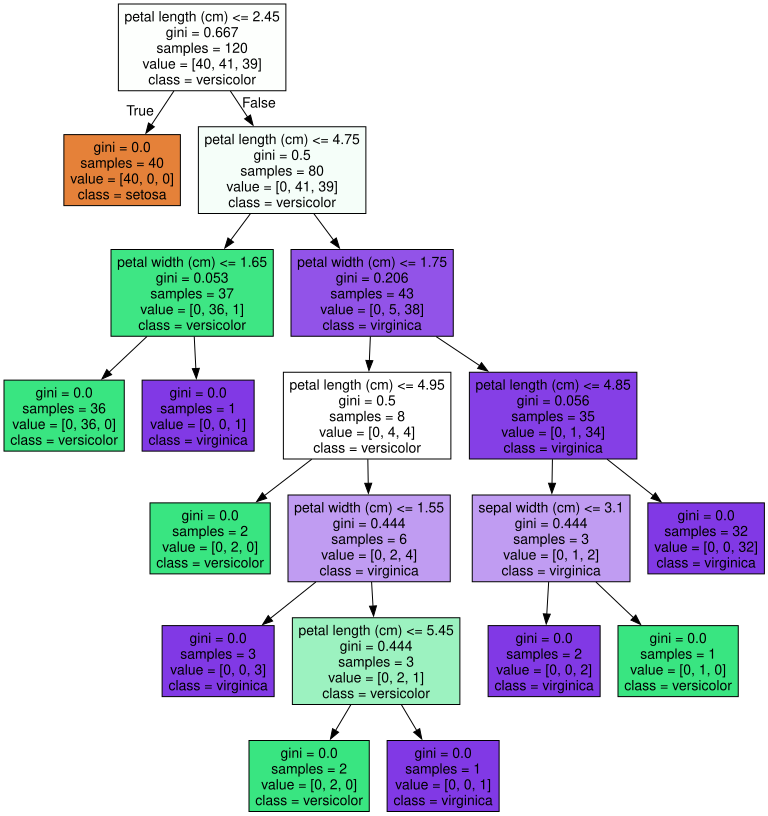

In [8]:
import graphviz

with open("tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)



Feature importances:
[0.    0.017 0.906 0.077]
sepal length (cm) : 0.000
sepal width (cm) : 0.017
petal length (cm) : 0.906
petal width (cm) : 0.077


<Axes: >

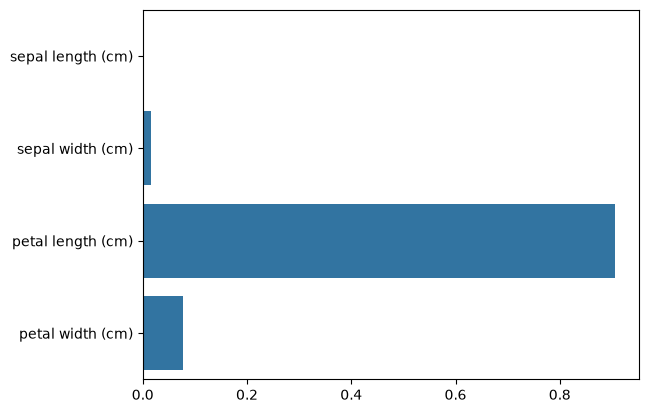

In [9]:
import seaborn as sns
import numpy as np
%matplotlib inline

print("Feature importances:\n{0}".format(np.round(dt_clf.feature_importances_, 3)))

for name, value in zip(iris_data.feature_names , dt_clf.feature_importances_):
    print('{0} : {1:.3f}'.format(name, value))

sns.barplot(x=dt_clf.feature_importances_ , y=iris_data.feature_names)

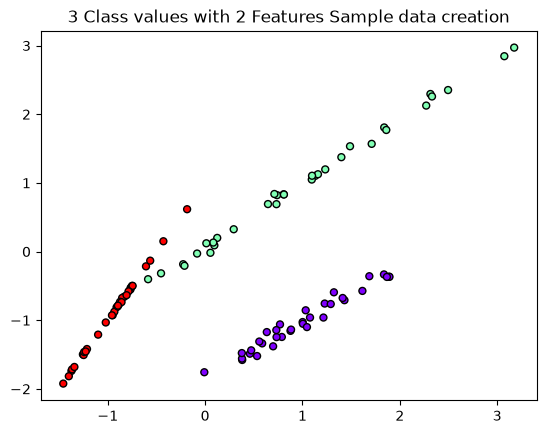

In [11]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
%matplotlib inline

plt.title("3 Class values with 2 Features Sample data creation")

X_features, y_labels = make_classification(n_features=2, n_redundant=0, n_informative=2,
                             n_classes=3, n_clusters_per_class=1,random_state=42)

plt.scatter(X_features[:, 0], X_features[:, 1], marker='o', c=y_labels, s=25, cmap='rainbow', edgecolor='k')

In [12]:
import numpy as np

def visualize_boundary(model, X, y):
    fig,ax = plt.subplots()
    
    ax.scatter(X[:, 0], X[:, 1], c=y, s=25, cmap='rainbow', edgecolor='k',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim_start , xlim_end = ax.get_xlim()
    ylim_start , ylim_end = ax.get_ylim()
    
    model.fit(X, y)

    xx, yy = np.meshgrid(np.linspace(xlim_start,xlim_end, num=200),np.linspace(ylim_start,ylim_end, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap='rainbow', clim=(y.min(), y.max()),
                           zorder=1)

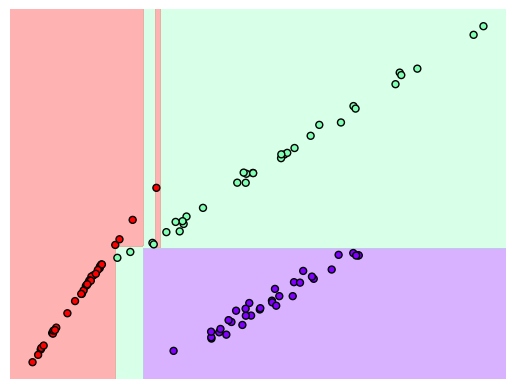

In [14]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=42).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)

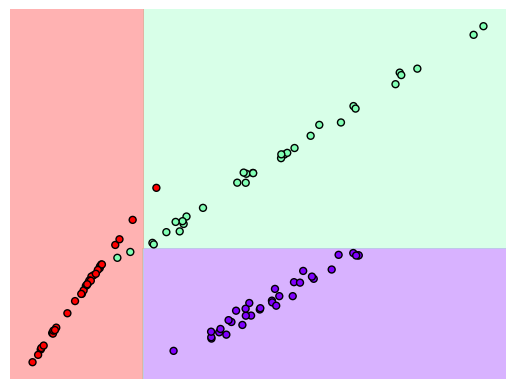

In [17]:
dt_clf = DecisionTreeClassifier(min_samples_leaf=6, random_state=42).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)

In [14]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

with open('./data/human_activity_train.csv', encoding="utf-8") as f:
    header = next(csv.reader(f))

feature_name_org = header[:-2]

feature_name_df = pd.DataFrame({
    "column_index": range(1, len(feature_name_org) + 1),
    "column_name": feature_name_org
})


feature_name = feature_name_df.iloc[:, 1].values.tolist()

print("전체 피쳐 개수:", len(feature_name))
print('전체 피처명에서 10개만 추출:', feature_name[:10])

전체 피쳐 개수: 561
전체 피처명에서 10개만 추출: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


In [15]:
feature_dup_df = feature_name_df.groupby('column_name').count()
print(feature_dup_df[feature_dup_df['column_index'] > 1].count())
feature_dup_df[feature_dup_df['column_index'] > 1].head()


column_index    42
dtype: int64


,column_index
column_name,
"fBodyAcc-bandsEnergy()-1,16",3
"fBodyAcc-bandsEnergy()-1,24",3
"fBodyAcc-bandsEnergy()-1,8",3
"fBodyAcc-bandsEnergy()-17,24",3
"fBodyAcc-bandsEnergy()-17,32",3


In [20]:
def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(
        data=old_feature_name_df.groupby('column_name').cumcount(),
        columns=['dup_cnt']
    )
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
    
    new_feature_name_df['column_name'] = new_feature_name_df.apply(
        lambda x: f"{x['column_name']}_{x['dup_cnt']}" if x['dup_cnt'] > 0 else x['column_name'], 
        axis=1
    )
    
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

In [21]:
import csv
import pandas as pd

ACTION_MAP = {"WALKING": 1, "WALKING_UPSTAIRS": 2, "WALKING_DOWNSTAIRS": 3, "SITTING": 4, "STANDING": 5, "LAYING": 6}

def get_human_dataset():
    train_file = "./data/human_activity_train.csv"
    test_file = "./data/human_activity_test.csv"

    with open(train_file, encoding="utf-8") as f:
        header = next(csv.reader(f))
        feature_name_org = header[:-2]

    feature_name_df = pd.DataFrame({
        "column_index": range(1, len(feature_name_org) + 1),
        "column_name": feature_name_org
    })

    new_feature_name_df = get_new_feature_name_df(feature_name_df)

    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
    col_names = feature_name + ["subject", "action"]

    train_df = pd.read_csv(train_file, header=0, names=col_names)
    test_df = pd.read_csv(test_file, header=0, names=col_names)

    X_train = train_df[feature_name]
    X_test = test_df[feature_name]

    y_train = train_df[["action"]].replace(ACTION_MAP)
    y_test = test_df[["action"]].replace(ACTION_MAP)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_human_dataset()
print("X_train:", X_train.shape, "X_test:", X_test.shape,
      "y_train:", y_train.shape, "y_test:", y_test.shape)   

X_train: (7352, 561) X_test: (2947, 561) y_train: (7352, 1) y_test: (2947, 1)


In [22]:
print("## 학습 피쳐 데이터셋 info()")
print(X_train.info())

## 학습 피쳐 데이터셋 info()
<class 'pandas.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, tBodyAcc-mean()-X to angle(Z,gravityMean)
dtypes: float64(561)
memory usage: 31.5 MB
None


In [23]:
print(y_train['action'].value_counts())

action
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64


In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

print(y_train.info())

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train , y_train.astype(int))
pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test.astype(int), pred)
print(accuracy)



<class 'pandas.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   action  7352 non-null   object
dtypes: object(1)
memory usage: 57.6+ KB
None
0.8622327790973872


In [30]:
print(dt_clf.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [35]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth' : [ 6, 8 ,10, 12, 16 ,20, 24]
}

grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy', cv=5, verbose=1 )
grid_cv.fit(X_train , y_train.astype(int))

print(grid_cv.best_score_)
print(grid_cv.best_params_)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
0.847940824188275
{'max_depth': 8}


In [36]:
cv_results_df = pd.DataFrame(grid_cv.cv_results_)

cv_results_df[['param_max_depth', 'mean_test_score']]

,param_max_depth,mean_test_score
0,6,0.846303
1,8,0.847941
2,10,0.840464
3,12,0.843319
4,16,0.845358
5,20,0.845086
6,24,0.847397


In [48]:
params = {
    'max_depth' : [ 8 , 12, 16 ,20], 
    'min_samples_split' : [16, 24],
}

grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy', cv=5, verbose=1 )
grid_cv.fit(X_train , y_train.astype(int))
print(grid_cv.best_score_)
print(grid_cv.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
0.8509322641361099
{'max_depth': 8, 'min_samples_split': 24}


In [49]:
best_df_clf = grid_cv.best_estimator_
pred1 = best_df_clf.predict(X_test)
accuracy = accuracy_score(y_test.astype(int) , pred1)
print(accuracy)

0.8686800135731252


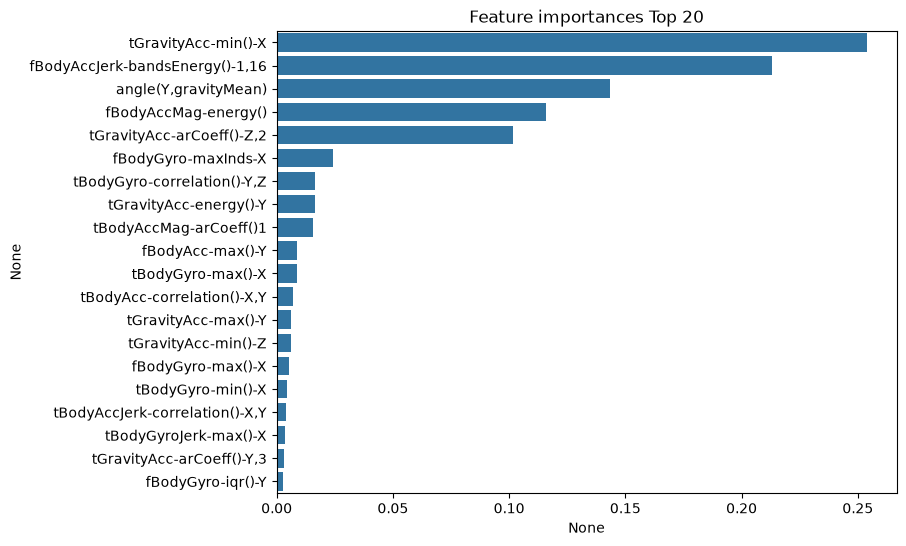

In [50]:
import seaborn as sns

ftr_importances_values = best_df_clf.feature_importances_

ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns  )

ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]
plt.figure(figsize=(8,6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20 , y = ftr_top20.index)
plt.show()